<a href="https://colab.research.google.com/github/jyothi070206/AI-Based-Fraud-Detection/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')
print("All libraries imported successfully")

All libraries imported successfully


In [2]:
df = pd.read_csv('Housing.csv')
print("Dataset loaded!")
df.head(10)

Dataset loaded!


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,9439081,8920,2,3,3,yes,no,yes,yes,no,1,yes,unfurnished
1,5896658,2510,3,2,2,yes,yes,no,yes,no,1,no,furnished
2,6848238,7040,4,1,2,yes,no,no,no,yes,2,no,furnished
3,8138178,15068,2,2,2,yes,no,no,no,no,3,no,unfurnished
4,6142010,6841,2,2,2,yes,no,yes,no,no,3,no,unfurnished
5,9985989,13614,6,2,1,yes,yes,no,yes,no,3,no,semi-furnished
6,7954439,12934,4,2,2,yes,no,no,no,no,1,no,semi-furnished
7,5973598,7384,1,3,2,no,no,no,no,no,1,yes,furnished
8,7217575,7915,3,2,4,yes,no,no,no,no,2,no,furnished
9,5724530,2116,3,2,1,no,no,yes,no,yes,3,no,semi-furnished


In [3]:
rows, cols = df.shape
print(f"Dataset Shape: {rows} rows x {cols} columns")
print()
print(df.dtypes)

Dataset Shape: 545 rows x 13 columns

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object


In [4]:
print("TARGET column: price")
print()
print("FEATURE columns:")
features = [col for col in df.columns if col != 'price']
for i, f in enumerate(features, 1):
    print(f"  {i}. {f}")

TARGET column: price

FEATURE columns:
  1. area
  2. bedrooms
  3. bathrooms
  4. stories
  5. mainroad
  6. guestroom
  7. basement
  8. hotwaterheating
  9. airconditioning
  10. parking
  11. prefarea
  12. furnishingstatus


In [5]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print()
print("Basic statistics:")
df.describe()

Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Basic statistics:


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,8.086931e+06,8815.911927,3.400000,2.264220,2.038532,1.253211
std,1.594701e+06,4137.463849,1.113751,0.882793,0.901582,0.843506
min,3.618786e+06,1654.000000,1.000000,1.000000,1.000000,0.000000
25%,7.090916e+06,5211.000000,3.000000,2.000000,1.000000,1.000000
50%,7.970944e+06,8672.000000,3.000000,2.000000,2.000000,1.000000
75%,8.992783e+06,12517.000000,4.000000,3.000000,3.000000,2.000000
max,1.393197e+07,16191.000000,6.000000,4.000000,4.000000,3.000000


In [6]:
df_clean = df.copy()

# Fill missing values
for col in df_clean.select_dtypes(include=['int64','float64']).columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

for col in df_clean.select_dtypes(include=['object']).columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

# Remove duplicates
df_clean.drop_duplicates(inplace=True)

print(f"Missing values after cleaning: {df_clean.isnull().sum().sum()}")
print(f"Rows after removing duplicates: {len(df_clean)}")

Missing values after cleaning: 0
Rows after removing duplicates: 545


In [7]:
binary_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
for col in binary_cols:
    df_clean[col] = df_clean[col].map({'yes': 1, 'no': 0})

df_clean = pd.get_dummies(df_clean, columns=['furnishingstatus'], drop_first=True)

print("Columns after encoding:")
print(list(df_clean.columns))

Columns after encoding:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [8]:
X = df_clean.drop('price', axis=1)
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 436
Test samples: 109


In [9]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print(f"MAE  : {mae_lr:,.0f}")
print(f"RMSE : {rmse_lr:,.0f}")
print(f"R²   : {r2_lr:.4f}")

Linear Regression Results
MAE  : 357,028
RMSE : 449,172
R²   : 0.9184


In [10]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print(f"MAE  : {mae_rf:,.0f}")
print(f"RMSE : {rmse_rf:,.0f}")
print(f"R²   : {r2_rf:.4f}")

Random Forest Results
MAE  : 579,041
RMSE : 772,913
R²   : 0.7583


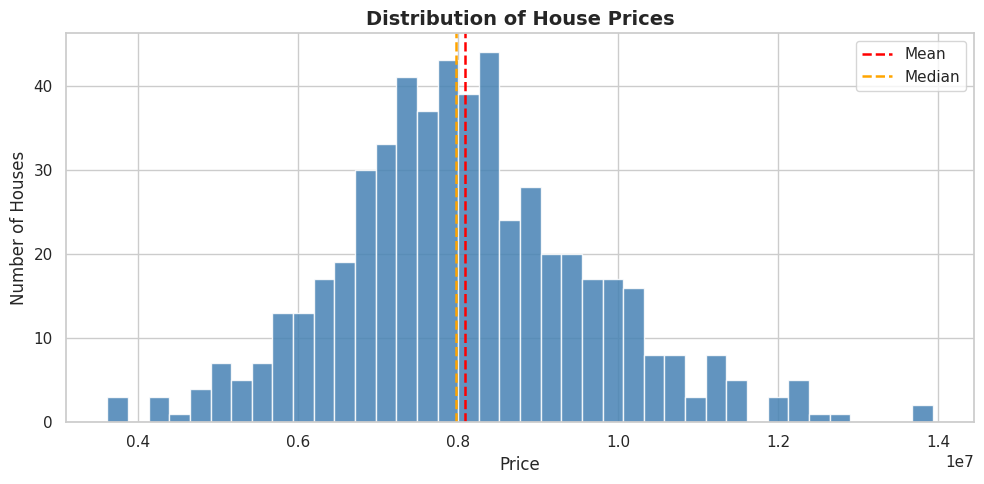

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_clean['price'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(df_clean['price'].mean(), color='red', linestyle='--', linewidth=1.8, label=f"Mean")
ax.axvline(df_clean['price'].median(), color='orange', linestyle='--', linewidth=1.8, label=f"Median")
ax.set_title('Distribution of House Prices', fontsize=14, fontweight='bold')
ax.set_xlabel('Price')
ax.set_ylabel('Number of Houses')
ax.legend()
plt.tight_layout()
plt.show()

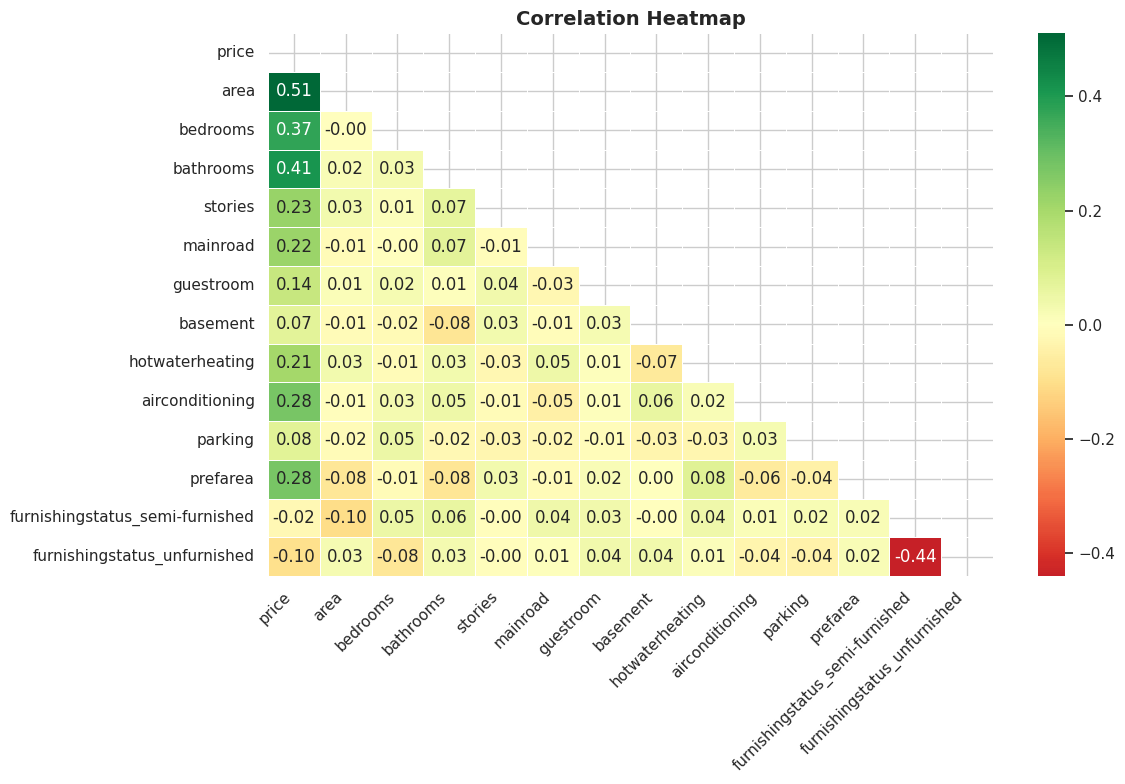

In [12]:
fig, ax = plt.subplots(figsize=(12, 8))
corr_matrix = df_clean.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

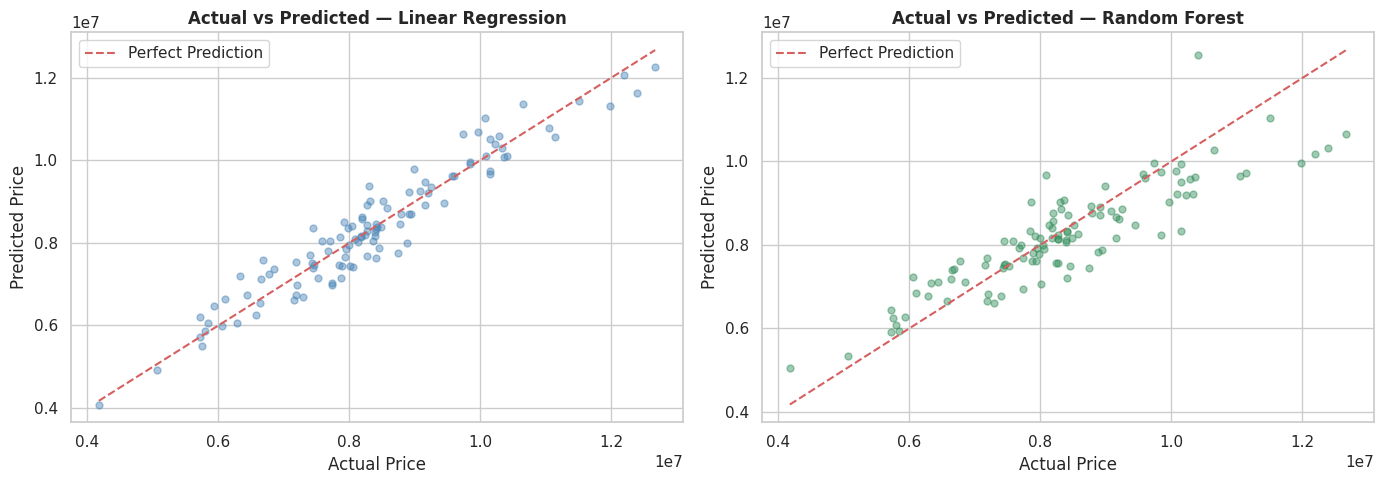

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title, color in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Linear Regression', 'Random Forest'],
    ['steelblue', 'seagreen']
):
    ax.scatter(y_test, y_pred, alpha=0.45, color=color, s=25)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5, label='Perfect Prediction')
    ax.set_title(f'Actual vs Predicted — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.legend()

plt.tight_layout()
plt.show()

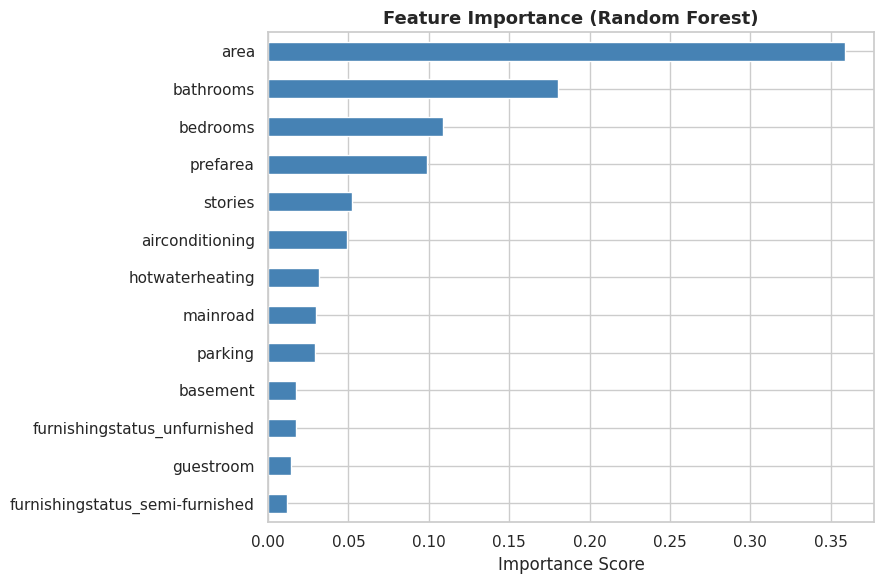

In [14]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
feat_imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature Importance (Random Forest)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [15]:
print("=" * 50)
print("        HOUSE PRICE PREDICTION SUMMARY")
print("=" * 50)
print(f"LINEAR REGRESSION  →  R² = {r2_lr:.4f}")
print(f"RANDOM FOREST      →  R² = {r2_rf:.4f}")
best = 'Random Forest' if r2_rf > r2_lr else 'Linear Regression'
print(f"Best Model: {best}")
print("=" * 50)

        HOUSE PRICE PREDICTION SUMMARY
LINEAR REGRESSION  →  R² = 0.9184
RANDOM FOREST      →  R² = 0.7583
Best Model: Linear Regression
